# Example workflow part 2

In this case we only need one more class (at least on subject level). So the Base_project class is a bit unnecessary. But imagine different data types or classes for different analysis and it all makes sense.
We'll now inherit from the class and add the analysis class on top of this:

In [17]:
import numpy as np
from scipy import stats
import os
from ipdb import set_trace
from Base_project import Base_project

#these I added one after the other when needed
import pickle
import pandas as pd
import seaborn as sns
from scipy.stats import linregress
from matplotlib import pyplot as plt

There's one more trick. Remember how we ran `list_subjects` in the `__init__ ` method of Base_project? We're overwriting the `__init__`method in the new class. So that doesn't get called by default, but it would be nice. We can call the `__init__`-method of the superclass (the one we inherit) from like this:

In [18]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;

In [19]:
s = Subject(2);
print( s.subjects)

['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's09', 's10', 's11', 's12', 's13', 's14', 's15']


Looking at the assignment we can already think about a few methods we will need:

In [8]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;
        
    #we will have to load the data
    def load_data(self):
        pass
    
    #we will use a linear regression
    def run_regression(self):
        pass
    
    #we have to convert the sequence of foodIDs into a 
    def convert_seq(self):
        pass
    
    #a function that plots reaction times against ratings
    def plot(self):
        pass    

Let's start with the `__init__`-method. It should raise an error if the subject doesn't exist. This information is already in the object thanks to the `super().__init__()` -part. So we can just check like this:

In [9]:
subID = 10
s.subject_exists( subID)

True

and in the init method:

In [10]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;
        if not self.subject_exists(subID):
            raise Exception('No such subject in the directory ' + self.path)
        

In [11]:
s = Subject(99)

Exception: No such subject in the directory C:/Users/neugebauer/Documents/Python_workshop/toy_data/

okay. The obvious first step is to load the data into the object. The data is in .csv-files. You would now google for a way to read those into python. You could add `numpy` or `pandas` in your search because you know you will use these packages to handle the data. I usually would use pandas for this, but we'll stick to numpy for now.

You will somehow find out that `np.genfromtxt` is probably what you're looking for.

In [12]:
np.genfromtxt?

Signature:
np.genfromtxt(
    fname,
    dtype=<class 'float'>,
    comments='#',
    delimiter=None,
    skip_header=0,
    skip_footer=0,
    converters=None,
    missing_values=None,
    filling_values=None,
    usecols=None,
    names=None,
    excludelist=None,
    deletechars=None,
    replace_space='_',
    autostrip=False,
    case_sensitive=True,
    defaultfmt='f%i',
    unpack=None,
    usemask=False,
    loose=True,
    invalid_raise=True,
    max_rows=None,
    encoding='bytes',
)
Docstring:
Load data from a text file, with missing values handled as specified.

Each line past the first `skip_header` lines is split at the `delimiter`
character, and characters following the `comments` character are discarded.

Parameters
----------
fname : file, str, pathlib.Path, list of str, generator
    File, filename, list, or generator to read.  If the filename
    extension is `.gz` or `.bz2`, the file is first decompressed. Note
    that generators must return byte strings in Python 

You see that there's a whole lot of options here. In our case the files are comma separated, so let's just try it out in the simplest way:

In [13]:
s = Subject(1);
pth = s. path_to_data(1,'food');
print(pth)

C:/Users/neugebauer/Documents/Python_workshop/toy_data/s01\food_ratings.csv


In [14]:
test = np.genfromtxt(pth, delimiter = ',');
print(test)

[[ 1.  2.]
 [ 2.  9.]
 [ 3.  7.]
 [ 4.  4.]
 [ 5. 18.]
 [ 6.  9.]
 [ 7.  6.]
 [ 8. 13.]
 [ 9. 17.]
 [10.  7.]
 [11. 16.]
 [12.  7.]
 [13. 13.]
 [14.  3.]
 [15.  5.]
 [16. 20.]
 [17. 12.]
 [18.  2.]
 [19.  9.]
 [20. 11.]
 [21. 20.]
 [22. 13.]
 [23.  7.]
 [24.  3.]
 [25.  5.]
 [26. 11.]
 [27. 14.]
 [28. 16.]
 [29.  5.]
 [30.  7.]]


That looks good. In readcion times there are floats and integers, that might be harder...

In [15]:
pth2 = s.path_to_data(1,'RT');

In [16]:
t2 = np.genfromtxt( pth2 );
print(t2)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]


Yeah, that looks bad. Either, you try to work around it, or you hope the pandas people have done this for you and try again using pandas:


In [17]:
import pandas as pd
t2 = pd.read_csv(pth2);
t2.head()


,29.0,0.3874505638951348
0,19.0,0.484971
1,7.0,0.531008
2,11.0,0.411700
3,7.0,0.256366
4,24.0,0.555504


Unfortunately, this steals the first row and uses it as names for columns. There sure is a way around that:

In [18]:
pd.read_csv?

Signature:
pd.read_csv(
    filepath_or_buffer,
    sep=',',
    delimiter=None,
    header='infer',
    names=None,
    index_col=None,
    usecols=None,
    squeeze=False,
    prefix=None,
    mangle_dupe_cols=True,
    dtype=None,
    engine=None,
    converters=None,
    true_values=None,
    false_values=None,
    skipinitialspace=False,
    skiprows=None,
    skipfooter=0,
    nrows=None,
    na_values=None,
    keep_default_na=True,
    na_filter=True,
    verbose=False,
    skip_blank_lines=True,
    parse_dates=False,
    infer_datetime_format=False,
    keep_date_col=False,
    date_parser=None,
    dayfirst=False,
    iterator=False,
    chunksize=None,
    compression='infer',
    thousands=None,
    decimal=b'.',
    lineterminator=None,
    quotechar='"',
    quoting=0,
    doublequote=True,
    escapechar=None,
    comment=None,
    encoding=None,
    dialect=None,
    tupleize_cols=None,
    error_bad_lines=True,
    warn_bad_lines=True,
    delim_whitespace=False,
    

`header` could be worth a try. Usually passing `None` works in cases like this:

In [19]:
import pandas as pd
t2 = pd.read_csv(pth2, header = None);
t2.head()

,0,1
0,29.0,0.387451
1,19.0,0.484971
2,7.0,0.531008
3,11.0,0.411700
4,7.0,0.256366


Thanks, pandas people! We won't use pandas for the analysis, but for input/output is usually way easier to use than numpy. Plus, it implements many things you might know from R like groupby, column names and head. It's the OOP version of R DataFrames. The best of both worlds! 

Let's have a look at the type of what we got back

In [20]:
print(type(t2))

<class 'pandas.core.frame.DataFrame'>


okay, a DataFrame. As usual, we can use `np.array` to convert other objects into arrays. Or we use the fact, that pandas is a wrapper around numpy and we can get the `values` attribute, which is the raw array:

In [21]:
t2_array = t2.values;
print(type(t2_array));
print(t2_array[:10,:])

<class 'numpy.ndarray'>
[[29.          0.38745056]
 [19.          0.48497081]
 [ 7.          0.53100802]
 [11.          0.41169963]
 [ 7.          0.25636602]
 [24.          0.55550408]
 [23.          1.04104525]
 [21.          0.41044408]
 [ 1.          0.4713283 ]
 [ 1.          0.73012736]]


that is a good approach. So for all of the files we will first read them using pandas and then convert them to np.arrays:

In [22]:
def read_data(subject, typ):
    path = subject.path_to_data( subject.subID, typ);
    df = pd.read_csv( path );
    return df.values

In [23]:
array= read_data( s, 'food');
print(array)

[[ 2  9]
 [ 3  7]
 [ 4  4]
 [ 5 18]
 [ 6  9]
 [ 7  6]
 [ 8 13]
 [ 9 17]
 [10  7]
 [11 16]
 [12  7]
 [13 13]
 [14  3]
 [15  5]
 [16 20]
 [17 12]
 [18  2]
 [19  9]
 [20 11]
 [21 20]
 [22 13]
 [23  7]
 [24  3]
 [25  5]
 [26 11]
 [27 14]
 [28 16]
 [29  5]
 [30  7]]


A few google searches and a bit of coding and we might arrive here:

In [24]:
def load_data(subject):
    
    load_rating(subject);
    load_RT(subject);
    
def load_rating(subject):
    
    path = subjects.path_to_data( subjects.subID, 'food' );
    subject.rating = pd.read_csv(path, header = None ).values;
    
def load_RT(subject):
    path = subject.path_to_data( subjects.subID, 'RT' );
    dummy = pd.read_csv( path , header = None ).values;
    subject.RT = dummy[:,1];
    subject.seq = dummy[:,0];

We could also load the rating_seq, but to convert this from the ratings and the sequence is part of the assigment, so we don't. In the class:

In [25]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;
        
    #we will have to load the data
    def load_data(self):
        self.load_rating();
        self.load_RT();
        
    def load_rating(self):
        path = self.path_to_data( self.subID, 'food' );
        self.rating = pd.read_csv(path, header = None).values;
    
    def load_RT(self):
        path = self.path_to_data( self.subID, 'RT' );
        dummy = pd.read_csv( path, header = None ).values;
        self.RT = dummy[:,1]; # second column are RTs
        self.seq = dummy[:,0]; # first column is sequence
    
    #we will use a linear regression
    def run_regression(self):
        pass
    
    #we have to convert the sequence of foodIDs into a 
    def convert_seq(self):
        pass
    
    #a function that plots reaction times against ratings
    def plot(self):
        pass    

In [26]:
s = Subject(1);
s.load_data();
print(s.rating)

[[ 1  2]
 [ 2  9]
 [ 3  7]
 [ 4  4]
 [ 5 18]
 [ 6  9]
 [ 7  6]
 [ 8 13]
 [ 9 17]
 [10  7]
 [11 16]
 [12  7]
 [13 13]
 [14  3]
 [15  5]
 [16 20]
 [17 12]
 [18  2]
 [19  9]
 [20 11]
 [21 20]
 [22 13]
 [23  7]
 [24  3]
 [25  5]
 [26 11]
 [27 14]
 [28 16]
 [29  5]
 [30  7]]


Works fine until here. Trying to convert the sequence of food_ids into a sequence of ratings. You could do something like this:

In [30]:
seq = s.seq;
rate = s.rating

In [79]:
rate_seq = np.zeros(seq.shape)
for i,s in enumerate(seq):
    rating = rate[rate[:,0] == s,1]
    
    rate_seq[i] = rating;
print(rate_seq[:10])  

[ 5.  9.  6. 16.  6.  3.  7. 20.  2.  2.]


In [78]:
#but probably list comprehension is quicker
rate_seq = np.array( [rate[ rate[:,0] == s, 1] for s in seq ]);
print(rate_seq[:10])

[[ 5]
 [ 9]
 [ 6]
 [16]
 [ 6]
 [ 3]
 [ 7]
 [20]
 [ 2]
 [ 2]]


In [33]:
def convert_seq(subject):
    subject.rate_seq = np.array( [ rate[ rate[:,0] == s, 1] for s in subject.seq ] );

and in the class:

In [34]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;
        
    #we will have to load the data
    def load_data(self):
        self.load_rating();
        self.load_RT();
        
    def load_rating(self):
        path = self.path_to_data( self.subID, 'food' );
        self.rating = pd.read_csv(path, header = None).values;
    
    def load_RT(self):
        path = self.path_to_data( self.subID, 'RT' );
        dummy = pd.read_csv( path, header = None ).values;
        self.RT = dummy[:,1]; # second column are RTs
        self.seq = dummy[:,0]; # first column is sequence
        
    #we have to convert the sequence of foodIDs into a 
    def convert_seq(self):
        self.rate_seq = np.array( [ rate[ rate[:,0] == s, 1] for s in self.seq ] );
    
    #we will use a linear regression
    def run_regression(self):
        pass
    
    #a function that plots reaction times against ratings
    def plot(self):
        pass    

Now the data can be easily loaded into the object and we can start to think about the analysis. There's tons of ways you can fit a regression in Python. We'll stay basic and use `scipy` for this:

In [35]:
from scipy import stats

Now we find out how the function is called in scipy and how it works. You can use tab completion and a prior idea about what it might be called. Or google.

In [36]:
stats.linregress?

Signature: stats.linregress(x, y=None)
Docstring:
Calculate a linear least-squares regression for two sets of measurements.

Parameters
----------
x, y : array_like
    Two sets of measurements.  Both arrays should have the same length.
    If only x is given (and y=None), then it must be a two-dimensional
    array where one dimension has length 2.  The two sets of measurements
    are then found by splitting the array along the length-2 dimension.

Returns
-------
slope : float
    slope of the regression line
intercept : float
    intercept of the regression line
rvalue : float
    correlation coefficient
pvalue : float
    two-sided p-value for a hypothesis test whose null hypothesis is
    that the slope is zero, using Wald Test with t-distribution of
    the test statistic.
stderr : float
    Standard error of the estimated gradient.

See also
--------
:func:`scipy.optimize.curve_fit` : Use non-linear
 least squares to fit a function to data.
:func:`scipy.optimize.leastsq` : Mini

Yeah, that was pretty easy. Okay, so we regress the reaction times (which usually of course would have to be log-transformed because they would be pretty skewed. We'll skip this. The idea here is to show how you use a notebook and classes for analysis.) onto ratings. Which means use ratings (x) to predict RT (y)

In [39]:
#since we only need the one function from scipy, we can directly import it (and add this to the first cell. Then you can copy all necessary imports into the script easily)

from scipy.stats import linregress

s = Subject(1);
s.load_data();
s.convert_seq();

In [38]:
rate_seq = s.rate_seq;
RT = s.RT;

In [40]:
test_out = linregress(x = rate_seq, y = RT )

ValueError: all the input array dimensions except for the concatenation axis must match exactly

In contrast to MATLAB, there is actually a difference between the shape (100,) and (100,1). Either you only have one dimension or you have a singleton dimension and these behave differently. Look at the two:

In [43]:
print(rate_seq.shape);
print(rate_seq[:5]);
print(RT.shape);
print(RT[:5]);

(150, 1)
[[ 5]
 [ 9]
 [ 6]
 [16]
 [ 6]]
(150,)
[0.38745056 0.48497081 0.53100802 0.41169963 0.25636602]


There's two ways around this. Add an empty dimension to the one-dimensional vector using either of the two ways:

In [44]:
#use expand_dims
RT1 = np.expand_dims( RT, axis= 1);
print(RT1[:5]);
#or add a new axis using np.newaxis and indexing:
RT2 = RT[:,np.newaxis];
print(RT2[:5]);

[[0.38745056]
 [0.48497081]
 [0.53100802]
 [0.41169963]
 [0.25636602]]
[[0.38745056]
 [0.48497081]
 [0.53100802]
 [0.41169963]
 [0.25636602]]


Or delete the empty dimension from the fake matrix:

In [45]:
rate_seq2 = rate_seq.squeeze();
print(rate_seq2);

[ 5  9  6 16  6  3  7 20  2  2  3  6 11  6 18  7  9 11 20 17 17  4 13  7
  2 18 13  4  2  5 13  9 16 12  5 18 13 13  9  5  7  4 13 14  7 20 17  7
  7  7  3 16  7 16  9  3 13 16  9  3  9 11  5  4 16  7 13  6 17 11  5  7
 12  5  7  7  7  9  2 14 12  3 20  7  9 11  3  4  7  5  3 20 12  9 11 18
  5 13  9  7  7  2 11 13  7  7 20 20 14  7  5  2  7 12 16 17 16  7  7  9
 13 13  5 11  3 16  5  2  3  2  5 11  5 13  2 16  9  5 14  9 20  9 20  7
 13 14 11 18 13 20]


In [46]:
#next try:
test_out = linregress( x= rate_seq2, y = RT  )

In [47]:
print(test_out)

LinregressResult(slope=-0.004270904982764135, intercept=0.4698033891523923, rvalue=-0.10939920972921509, pvalue=0.1826446398325837, stderr=0.0031897770661547943)


In [52]:
#how can we index this. lets try dict-like indexing:
test_out['slope']

TypeError: tuple indices must be integers or slices, not str

Okay, so this is is nothing but a fancy tuple. A dictionary would be a nice data type for the results. We can build one from the output like this:

In [53]:
results = dict( zip( ['slope','intercept', 'corr', 'p', 'SE' ], test_out) );
print(results)

{'slope': -0.004270904982764135, 'intercept': 0.4698033891523923, 'corr': -0.10939920972921509, 'p': 0.1826446398325837, 'SE': 0.0031897770661547943}


In [55]:
#make it a function

def fit_regression(subject):
    result_names = ['slope', 'intercept', 'corr', 'p', 'SE' ];
    out = linregress( subject.rate_seq.squeeze(), subject.RT );
    self.result = dict(zip(result_names,out));

In our case there is next to no computation cost, so we could just compute this over and over again. If you need to do time-costly analysis, it's a good idea to save the results and check if they're there already computed. In this case we could just load them and only have to run the analysis once:

In [57]:
s.path_to_data(s.subID, 'food' )

'C:/Users/neugebauer/Documents/Python_workshop/toy_data/s01\\food_ratings.csv'

We could go back to the base project class and add an option to look for the linregress results. Or we are lazy and to it like this:

In [58]:
s.path_to_data(s.subID, 'food' ).replace( 'food_ratings.csv', 'linreg_result.pic')

'C:/Users/neugebauer/Documents/Python_workshop/toy_data/s01\\linreg_result.pic'

Not pretty,but it works. We use pickle for the load/save thingy:

In [71]:
#make it a function

def fit_regression(subject):
    
    savename = subject.path_to_data( subject.subID, 'food').replace( 'food_ratings.csv', 'linreg_result.pic' );
    #check if you already saved it before, if yes unpickle
    if os.path.exists(savename):
        print('Found pickled version.')
        with open(savename, 'rb') as f:
            out = pickle.load( f );
    #otherwise, run regression and pickle, so next time you just load the result
    else:
        print('Running analysis now.')
        out = linregress( subject.rate_seq.squeeze(), subject.RT );
        with open(savename,'wb') as f:
            pickle.dump(out, f, -1 );
    #make it a dict and part of the object:
    result_names = ['slope', 'intercept', 'corr', 'p', 'SE' ];
    subject.result = dict(zip(result_names,out));

oh yeah... add it on top, too

In [73]:
import pickle
s = Subject(1);
s.load_data();
s.convert_seq()
fit_regression(s)

Running analysis now.


In [74]:
#check second time:
fit_regression(s)

Found pickled version.


Cool. Now, again, replace `subject` with `self` and make it part of the class:

In [84]:
class Subject( Base_project):
    
    def __init__(self,subID):
        super().__init__();
        self.subID = subID;
        
    #we will have to load the data
    def load_data(self):
        self.load_rating();
        self.load_RT();
        
    def load_rating(self):
        path = self.path_to_data( self.subID, 'food' );
        self.rating = pd.read_csv(path, header = None).values;
    
    def load_RT(self):
        path = self.path_to_data( self.subID, 'RT' );
        dummy = pd.read_csv( path, header = None ).values;
        self.RT = dummy[:,1]; # second column are RTs
        self.seq = dummy[:,0]; # first column is sequence
        
    #we have to convert the sequence of foodIDs into a 
    def convert_seq(self):
        self.rate_seq = np.array( [ rate[ rate[:,0] == s, 1] for s in self.seq ] );
    
    #we will use a linear regression
    def fit_regression(self):
        savename = self.path_to_data( self.subID, 'food').replace( 'food_ratings.csv', 'linreg_result.pic' );
        #check if you already saved it before, if yes unpickle
        if os.path.exists(savename):
            print('Found pickled version.')
            with open(savename, 'rb') as f:
                out = pickle.load( f );
        #otherwise, run regression and pickle, so next time you just load the result
        else:
            print('Running analysis now.')
            out = linregress( self.rate_seq.squeeze(), self.RT );
            with open(savename,'wb') as f:
                pickle.dump(out, f, -1 );
        #make it a dict and part of the object:
        result_names = ['slope', 'intercept', 'corr', 'p', 'SE' ];
        self.results = dict(zip(result_names,out));    
        #a function that plots reaction times against ratings
    
    def plot(self):
        pass    

Last but not least, we want to be able to plot this. We could also plot the regression line in there:

In [85]:
from matplotlib import pyplot as plt

In [88]:
s = Subject(1);
s.load_data();
s.convert_seq();
s.fit_regression();

results, RT, ratings = s.results, s.RT, s.rate_seq;

Found pickled version.


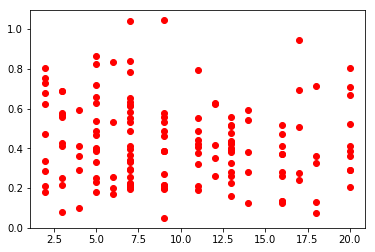

In [91]:
plt.plot(ratings,RT,'ro')

now to the regression line:

In [97]:
x_lim  = np.array( [ratings.min(), ratings.max()] );

In [98]:
y_hat = results['intercept'] + x_lim * results['slope']

In [99]:
y_hat

array([0.46126158, 0.38438529])

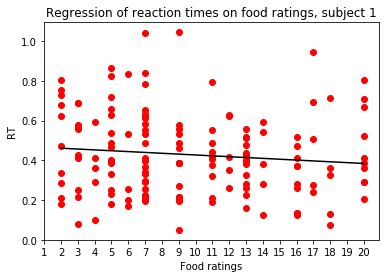

In [105]:
fig = plt.figure();
ax = fig.add_subplot(111);
ax.plot(ratings,RT,'ro');
ax.plot(x_lim,y_hat,'k-');
ax.set_xticks(np.arange(1,21));
ax.set_xlabel('Food ratings');
ax.set_ylabel('RT');
ax.set_title('Regression of reaction times on food ratings, subject {}'.format(s.subID))
plt.show()

We could be lazier and use seaborn for this:

In [106]:
import seaborn as sns;

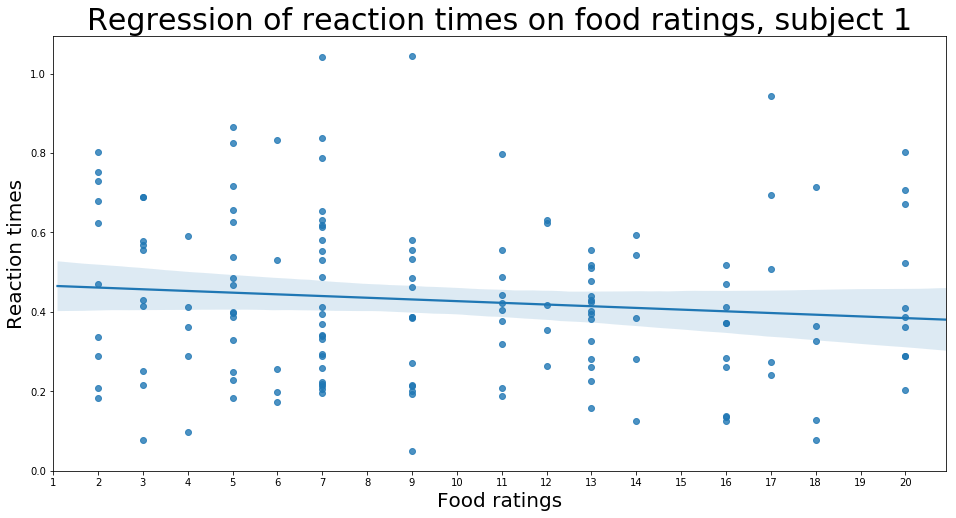

In [120]:
fig = plt.figure(figsize=(16,8));
ax = fig.add_subplot(111);
sns.regplot( ratings,RT, ax= ax ) ;
ax.set_xlabel('Food ratings',fontsize=20);
ax.set_ylabel('Reaction times',fontsize=20);
ax.set_xticks(np.arange(1,21) );
ax.set_title('Regression of reaction times on food ratings, subject {}'.format(s.subID), fontsize= 30)

plt.show()

You could spend a bit of time to make this nicer. But it's fine for now. The finished class could look like this:

In [16]:
class Subject( Base_project):
    
    def __init__(self,subID, run = False):
        super().__init__();
        self.subID = subID;
        if not self.subject_exists(subID):
            raise Exception('No such subject in the directory ' + self.path)
        #loading data while creating the object
        self.load_data();
        self.convert_seq();
        if run:
            self.fit_regression();
        
    #we will have to load the data
    def load_data(self):
        self.load_rating();
        self.load_RT();
        
    def load_rating(self):
        path = self.path_to_data( self.subID, 'food' );
        self.rating = pd.read_csv(path, header = None).values;
    
    def load_RT(self):
        path = self.path_to_data( self.subID, 'RT' );
        dummy = pd.read_csv( path, header = None ).values;
        self.RT = dummy[:,1]; # second column are RTs
        self.seq = dummy[:,0]; # first column is sequence
        
    #we have to convert the sequence of foodIDs into a 
    def convert_seq(self):
        self.rate_seq = np.array( [ self.rating[ self.rating[:,0] == s, 1] for s in self.seq ] );
    
    #we will use a linear regression
    def fit_regression(self):
        savename = self.path_to_data( self.subID, 'food').replace( 'food_ratings.csv', 'linreg_result.pic' );
        #check if you already saved it before, if yes unpickle
        if os.path.exists(savename):
            print('Found pickled version.')
            with open(savename, 'rb') as f:
                out = pickle.load( f );
        #otherwise, run regression and pickle, so next time you just load the result
        else:
            print('Running analysis now.')
            out = linregress( self.rate_seq.squeeze(), self.RT );
            with open(savename,'wb') as f:
                pickle.dump(out, f, -1 );
        #make it a dict and part of the object:
        result_names = ['slope', 'intercept', 'corr', 'p', 'SE' ];
        self.results = dict(zip(result_names,out));    
        #a function that plots reaction times against ratings
    
    def plot(self, show = False, save = True):
        fig = plt.figure(figsize=(16,8));
        ax = fig.add_subplot(111);
        sns.regplot( self.rate_seq, self.RT, ax= ax ) ;
        ax.set_xlabel('Food ratings',fontsize=20);
        ax.set_ylabel('Reaction times',fontsize=20);
        ax.set_xticks(np.arange(1,21) );
        ax.set_title('Regression of reaction times on food ratings, subject {}'.format(self.subID), fontsize= 25)
        if show:
            plt.show()
        if save:
            savename = self.path_to_data(self.subID, 'food').replace( 'food_ratings.csv', 'reg_plot.PNG' );
            if not os.path.exists(savename):
                fig.savefig( savename )

Found pickled version.


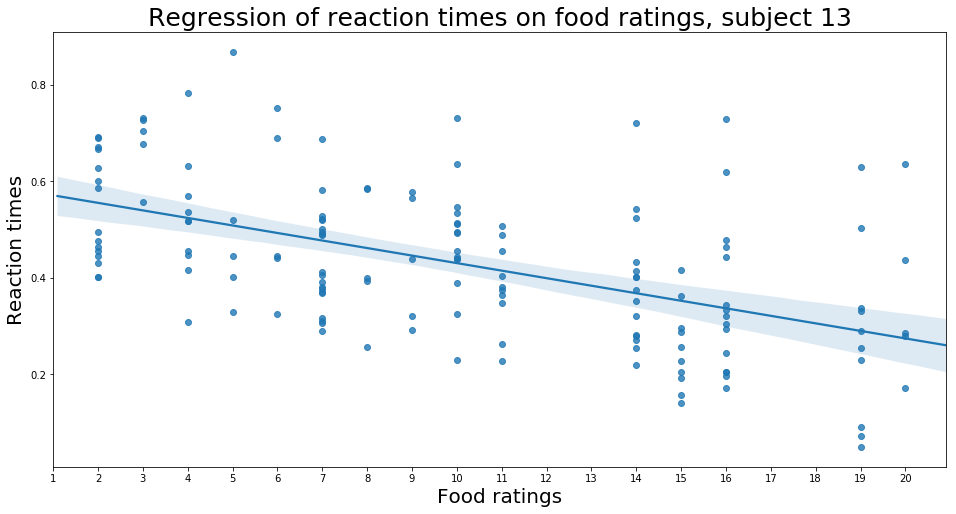

In [15]:
s = Subject(13)
s.fit_regression();
s.plot(save=True,show=True)

And that's pretty much it. Save the class in a module Subject.py or store both in the same module called Project.py or Project_classes.py or whatever.

Last step would be to write a script that makes use of these functions. You can find it in run_analysis.py.